# Las Griegas por diferenciación numérica

Las griegas son las derivadas del precio de la opción respecto a cada parámetro.
En lugar de usar las fórmulas cerradas, aquí se calculan **numéricamente**:
se genera una malla fina con `linspace`, se valúa la opción en cada punto y se
deriva con `np.gradient`.

| Griega | Derivada | Mide |
|---|---|---|
| Delta | $\partial V / \partial S$ | Sensibilidad al precio del activo |
| Gamma | $\partial^2 V / \partial S^2$ | Qué tan rápido cambia delta |
| Vega | $\partial V / \partial \sigma$ | Sensibilidad a la volatilidad |
| Theta | $-\partial V / \partial T$ | Pérdida de valor por el paso del tiempo |
| Rho | $\partial V / \partial r$ | Sensibilidad a la tasa de interés |

**Nota sobre el método:** se usa el mismo vector de números aleatorios `Z` para
todos los puntos de la malla. Sin esta técnica, llamada *common random numbers*,
cada punto tendría su propio ruido y las derivadas resultarían inservibles.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams['figure.figsize'] = (11, 5)

S0, K, r, sigma, T, M = 100, 100, 0.05, 0.20, 1, 10_000

np.random.seed(42)
Z = np.random.normal(0, 1, M)      # se reutiliza en toda la malla


def precio_mc(S0, K, r, sigma, T, Z, tipo='call'):
    ST = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    if tipo == 'call':
        return np.exp(-r*T) * np.maximum(ST - K, 0).mean()
    return np.exp(-r*T) * np.maximum(K - ST, 0).mean()


def precio_bs(S0, K, r, sigma, T, tipo='call'):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if tipo == 'call':
        return S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)

## 1. Delta y Gamma: sensibilidad al precio del activo

$S \in [80, 120]$, con los demás parámetros fijos.

In [2]:
S_malla = np.linspace(80, 120, 200)

call_S = np.array([precio_mc(s, K, r, sigma, T, Z, 'call') for s in S_malla])
put_S  = np.array([precio_mc(s, K, r, sigma, T, Z, 'put')  for s in S_malla])

delta_call = np.gradient(call_S, S_malla)
delta_put  = np.gradient(put_S,  S_malla)

gamma_call = np.gradient(delta_call, S_malla)
gamma_put  = np.gradient(delta_put,  S_malla)

print(f"Delta call en S = 100 : {np.interp(100, S_malla, delta_call):.4f}")
print(f"Delta put  en S = 100 : {np.interp(100, S_malla, delta_put):.4f}")
print(f"Gamma en S = 100      : {np.interp(100, S_malla, gamma_call):.4f}")
print(f"Delta call - Delta put: {np.interp(100, S_malla, delta_call - delta_put):.4f}")

Delta call en S = 100 : 0.6357
Delta put  en S = 100 : -0.3640
Gamma en S = 100      : 0.0172
Delta call - Delta put: 0.9997


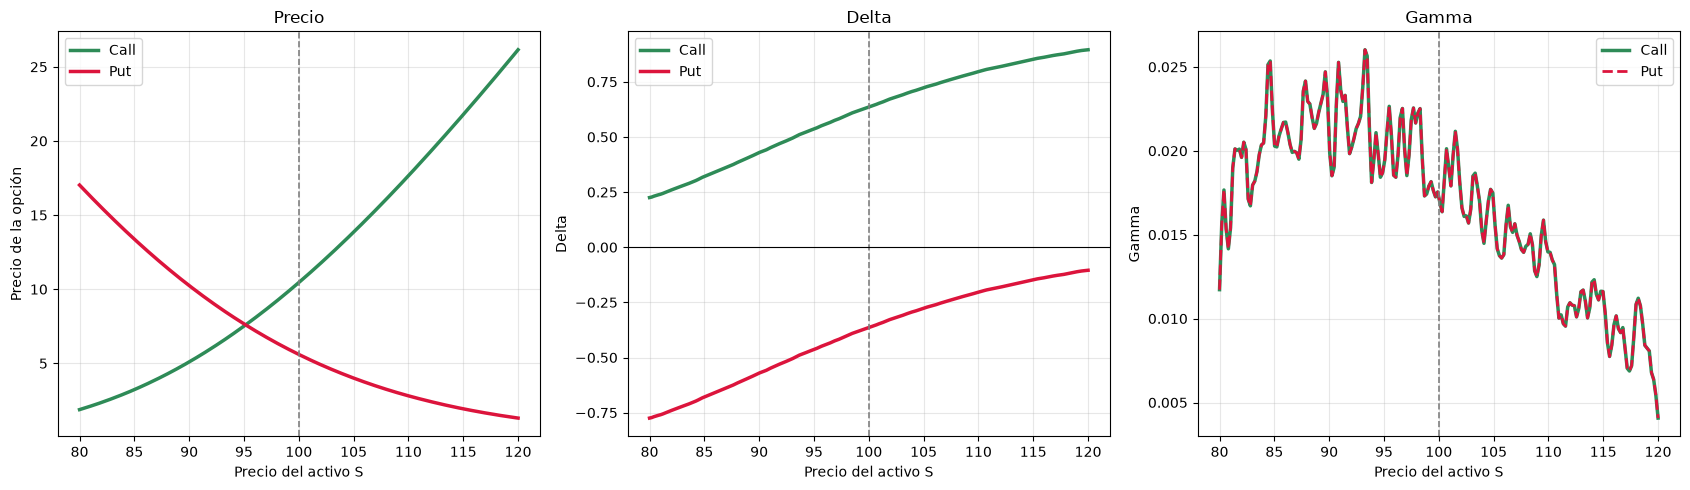

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(S_malla, call_S, lw=2.5, color='seagreen', label='Call')
axes[0].plot(S_malla, put_S,  lw=2.5, color='crimson',  label='Put')
axes[0].axvline(K, color='gray', ls='--', lw=1.2)
axes[0].set_xlabel('Precio del activo S'); axes[0].set_ylabel('Precio de la opción')
axes[0].set_title('Precio')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(S_malla, delta_call, lw=2.5, color='seagreen', label='Call')
axes[1].plot(S_malla, delta_put,  lw=2.5, color='crimson',  label='Put')
axes[1].axvline(K, color='gray', ls='--', lw=1.2)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xlabel('Precio del activo S'); axes[1].set_ylabel('Delta')
axes[1].set_title('Delta')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(S_malla, gamma_call, lw=2.5, color='seagreen', label='Call')
axes[2].plot(S_malla, gamma_put,  lw=2, ls='--', color='crimson', label='Put')
axes[2].axvline(K, color='gray', ls='--', lw=1.2)
axes[2].set_xlabel('Precio del activo S'); axes[2].set_ylabel('Gamma')
axes[2].set_title('Gamma')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Vega: sensibilidad a la volatilidad

$\sigma \in [5\%, 40\%]$.

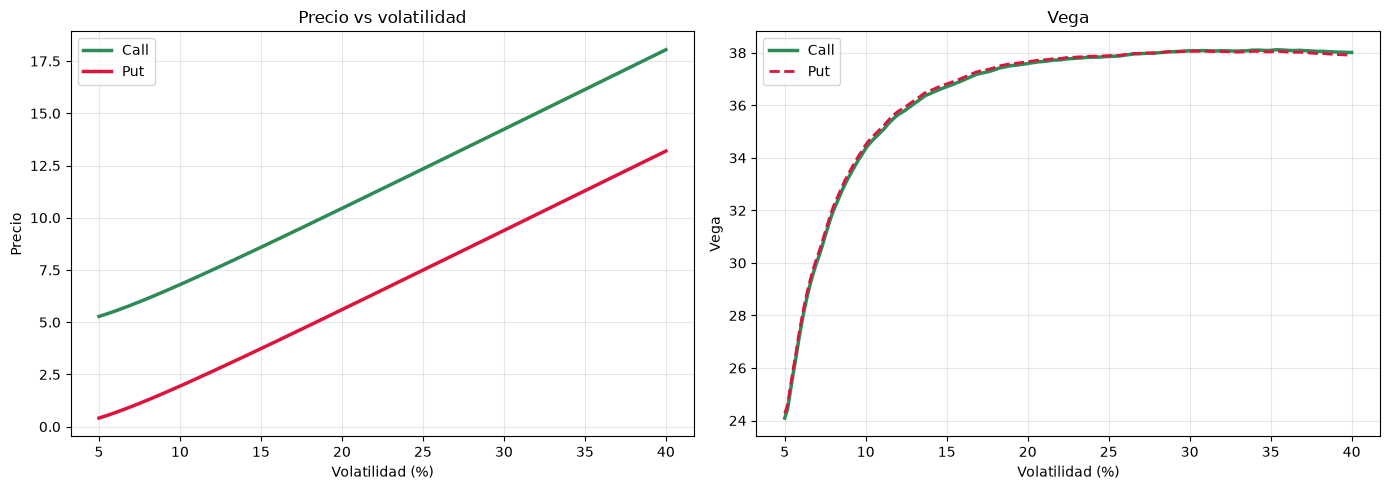

Vega en sigma = 20% : 37.5933
Por cada punto porcentual de sigma, el precio cambia 0.3759


In [4]:
sigma_malla = np.linspace(0.05, 0.40, 200)

call_sig = np.array([precio_mc(S0, K, r, s, T, Z, 'call') for s in sigma_malla])
put_sig  = np.array([precio_mc(S0, K, r, s, T, Z, 'put')  for s in sigma_malla])

vega_call = np.gradient(call_sig, sigma_malla)
vega_put  = np.gradient(put_sig,  sigma_malla)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sigma_malla*100, call_sig, lw=2.5, color='seagreen', label='Call')
axes[0].plot(sigma_malla*100, put_sig,  lw=2.5, color='crimson',  label='Put')
axes[0].set_xlabel('Volatilidad (%)'); axes[0].set_ylabel('Precio')
axes[0].set_title('Precio vs volatilidad')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(sigma_malla*100, vega_call, lw=2.5, color='seagreen', label='Call')
axes[1].plot(sigma_malla*100, vega_put,  lw=2, ls='--', color='crimson', label='Put')
axes[1].set_xlabel('Volatilidad (%)'); axes[1].set_ylabel('Vega')
axes[1].set_title('Vega')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Vega en sigma = 20% : {np.interp(0.20, sigma_malla, vega_call):.4f}")
print(f"Por cada punto porcentual de sigma, el precio cambia {np.interp(0.20, sigma_malla, vega_call)/100:.4f}")

## 3. Theta: sensibilidad al paso del tiempo

$T \in [0.25, 2]$ años.

Theta se define con signo negativo, $\theta = -\partial V / \partial T$, porque
mide la pérdida de valor conforme **transcurre** el tiempo, mientras que $T$ es
el tiempo que **falta** para el vencimiento. Las dos cosas se mueven en
direcciones opuestas.

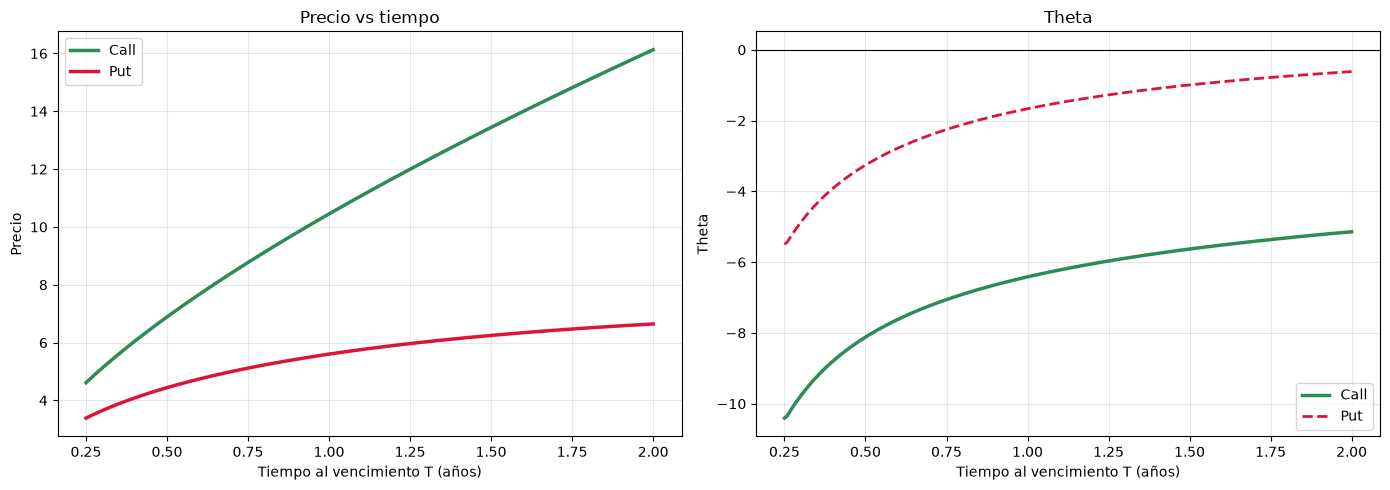

Theta call en T = 1 : -6.4156 por año
Equivale a -0.0176 por día


In [5]:
T_malla = np.linspace(0.25, 2, 200)

call_T = np.array([precio_mc(S0, K, r, sigma, t, Z, 'call') for t in T_malla])
put_T  = np.array([precio_mc(S0, K, r, sigma, t, Z, 'put')  for t in T_malla])

theta_call = -np.gradient(call_T, T_malla)
theta_put  = -np.gradient(put_T,  T_malla)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(T_malla, call_T, lw=2.5, color='seagreen', label='Call')
axes[0].plot(T_malla, put_T,  lw=2.5, color='crimson',  label='Put')
axes[0].set_xlabel('Tiempo al vencimiento T (años)'); axes[0].set_ylabel('Precio')
axes[0].set_title('Precio vs tiempo')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(T_malla, theta_call, lw=2.5, color='seagreen', label='Call')
axes[1].plot(T_malla, theta_put,  lw=2, ls='--', color='crimson', label='Put')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xlabel('Tiempo al vencimiento T (años)'); axes[1].set_ylabel('Theta')
axes[1].set_title('Theta')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Theta call en T = 1 : {np.interp(1, T_malla, theta_call):.4f} por año")
print(f"Equivale a {np.interp(1, T_malla, theta_call)/365:.4f} por día")

## 4. Rho: sensibilidad a la tasa libre de riesgo

$r \in [5\%, 40\%]$.

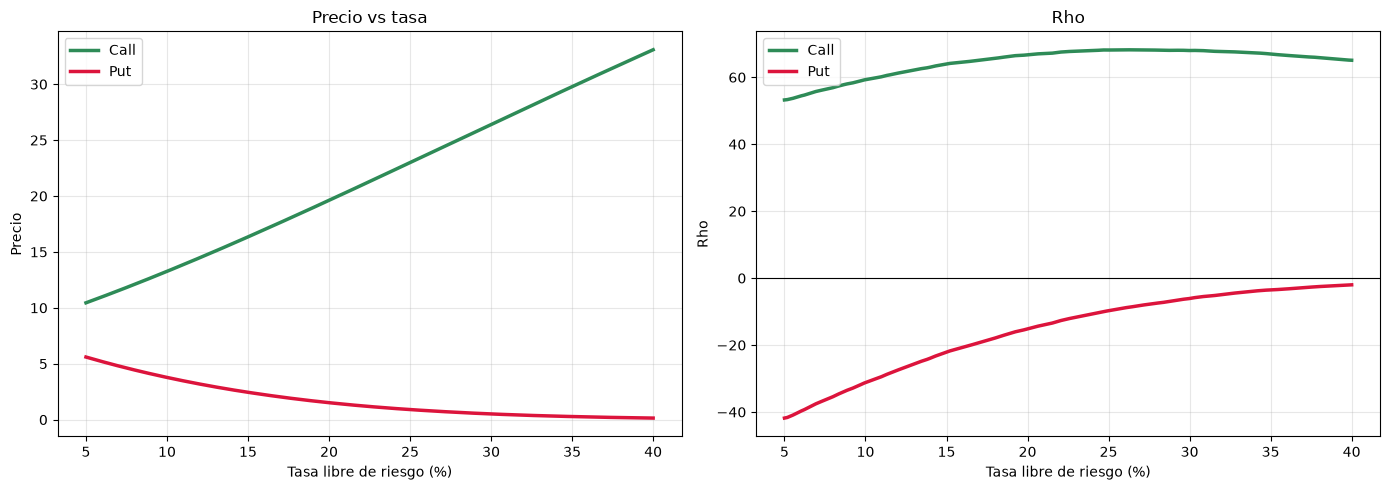

Rho call en r = 5% : 53.2304
Rho put  en r = 5% : -41.8090


In [6]:
r_malla = np.linspace(0.05, 0.40, 200)

call_r = np.array([precio_mc(S0, K, x, sigma, T, Z, 'call') for x in r_malla])
put_r  = np.array([precio_mc(S0, K, x, sigma, T, Z, 'put')  for x in r_malla])

rho_call = np.gradient(call_r, r_malla)
rho_put  = np.gradient(put_r,  r_malla)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(r_malla*100, call_r, lw=2.5, color='seagreen', label='Call')
axes[0].plot(r_malla*100, put_r,  lw=2.5, color='crimson',  label='Put')
axes[0].set_xlabel('Tasa libre de riesgo (%)'); axes[0].set_ylabel('Precio')
axes[0].set_title('Precio vs tasa')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(r_malla*100, rho_call, lw=2.5, color='seagreen', label='Call')
axes[1].plot(r_malla*100, rho_put,  lw=2.5, color='crimson',  label='Put')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xlabel('Tasa libre de riesgo (%)'); axes[1].set_ylabel('Rho')
axes[1].set_title('Rho')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Rho call en r = 5% : {np.interp(0.05, r_malla, rho_call):.4f}")
print(f"Rho put  en r = 5% : {np.interp(0.05, r_malla, rho_put):.4f}")

## 5. Validación contra las fórmulas analíticas

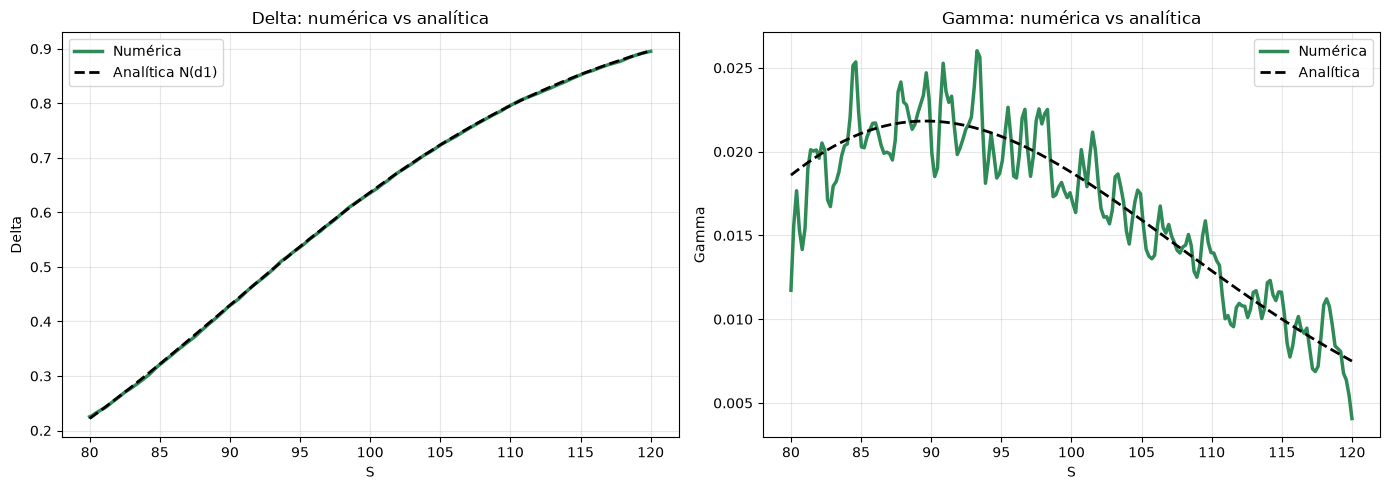

Error máximo delta : 0.00331
Error máximo gamma (interior) : 0.00495


In [7]:
d1 = (np.log(S_malla/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
delta_teorica = norm.cdf(d1)
gamma_teorica = norm.pdf(d1) / (S_malla * sigma * np.sqrt(T))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(S_malla, delta_call, lw=2.5, color='seagreen', label='Numérica')
axes[0].plot(S_malla, delta_teorica, ls='--', lw=2, color='black', label='Analítica N(d1)')
axes[0].set_xlabel('S'); axes[0].set_ylabel('Delta')
axes[0].set_title('Delta: numérica vs analítica')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(S_malla, gamma_call, lw=2.5, color='seagreen', label='Numérica')
axes[1].plot(S_malla, gamma_teorica, ls='--', lw=2, color='black', label='Analítica')
axes[1].set_xlabel('S'); axes[1].set_ylabel('Gamma')
axes[1].set_title('Gamma: numérica vs analítica')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

interior = slice(3, -3)
print(f"Error máximo delta : {np.abs(delta_call - delta_teorica).max():.5f}")
print(f"Error máximo gamma (interior) : {np.abs(gamma_call - gamma_teorica)[interior].max():.5f}")

---
# Ejercicio: decisiones financieras con griegas

Una institución diseña tres calls sobre una acción que cotiza en \$100. El objetivo no es solo leer las griegas, sino **usarlas para decidir** qué opción comprar o evitar según lo que se espera del mercado.

| Opción | K | T | Prima | Delta | Vega | Theta |
|---|---|---|---|---|---|---|
| A | 90 | 1/12 | 12 | 0.85 | 0.05 | −0.10 |
| B | 100 | 3/12 | 8 | 0.50 | 0.25 | −0.03 |
| C | 120 | 1 | 5 | 0.20 | 0.40 | −0.01 |


## Parte 1 - Observación

Las griegas en valor absoluto no bastan para comparar opciones con primas muy distintas: una Delta de 0.85 sobre una prima de 12 no pesa lo mismo que una Delta de 0.20 sobre una prima de 5. Por eso se calculan también sensibilidades **relativas a la prima** y se separa el valor intrínseco del valor temporal.

In [8]:
import pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

S_hoy = 100
op = pd.DataFrame({
    "K":     [90, 100, 120],
    "T":     [1/12, 3/12, 1],
    "Prima": [12, 8, 5],
    "Delta": [0.85, 0.50, 0.20],
    "Vega":  [0.05, 0.25, 0.40],
    "Theta": [-0.10, -0.03, -0.01],
}, index=["A", "B", "C"])

op["Intrinseco"]      = np.maximum(S_hoy - op["K"], 0)
op["Valor temporal"]  = op["Prima"] - op["Intrinseco"]
op["% temporal"]      = op["Valor temporal"] / op["Prima"]
op["Elasticidad"]     = op["Delta"] * S_hoy / op["Prima"]      # % cambio opcion / % cambio accion
op["Vega/Prima"]      = op["Vega"] / op["Prima"]
op["Theta/Prima"]     = op["Theta"] / op["Prima"]
op["Theta/V.temporal"] = op["Theta"] / op["Valor temporal"]
op["Breakeven"]       = op["K"] + op["Prima"]
op["Alza necesaria"]  = op["Breakeven"] / S_hoy - 1
op["Situacion"]       = ["ITM (dentro del dinero)", "ATM (en el dinero)", "OTM (fuera del dinero)"]

print(op[["K", "T", "Prima", "Intrinseco", "Valor temporal", "% temporal", "Situacion"]].to_string())
print()
print(op[["Elasticidad", "Vega/Prima", "Theta/Prima", "Theta/V.temporal",
          "Breakeven", "Alza necesaria"]].to_string())

     K      T  Prima  Intrinseco  Valor temporal  % temporal                Situacion
A   90 0.0833     12          10               2      0.1667  ITM (dentro del dinero)
B  100 0.2500      8           0               8      1.0000       ATM (en el dinero)
C  120 1.0000      5           0               5      1.0000   OTM (fuera del dinero)

   Elasticidad  Vega/Prima  Theta/Prima  Theta/V.temporal  Breakeven  Alza necesaria
A       7.0833      0.0042      -0.0083           -0.0500        102          0.0200
B       6.2500      0.0312      -0.0037           -0.0037        108          0.0800
C       4.0000      0.0800      -0.0020           -0.0020        125          0.2500


### Respuestas

**1. ¿Cuál es más sensible al precio de la acción?** **Opción A.** Tiene la Delta más alta (0.85): gana 85 centavos por cada peso que sube la acción. La conclusión se sostiene también en términos relativos: su elasticidad es 7.08, es decir, un alza de 1% en la acción mueve la prima alrededor de 7.1%, frente a 6.25 de B y 4.0 de C.

**2. ¿Cuál es más sensible a la volatilidad?** **Opción C.** Tiene la Vega más alta (0.40) y además la más relevante frente a su precio: cada punto porcentual de volatilidad mueve 8% de su prima, contra 3.1% en B y apenas 0.4% en A. Su vencimiento a un año amplifica el efecto, porque hay más tiempo para que la incertidumbre se traduzca en un movimiento grande.

**3. ¿Cuál se deteriora más rápido con el tiempo?** **Opción A.** Su Theta (−0.10) es la mayor en valor absoluto y equivale a 0.83% de la prima por día. Pero la cifra reveladora es otra: A solo tiene 2 pesos de valor temporal, así que pierde 5% de su valor temporal cada día. Vence en un mes, y el decaimiento temporal se acelera conforme se acerca el vencimiento.

**4. ¿Cuál se comporta más parecido a la acción?** **Opción A.** Delta cercana a 1, Vega casi nula y 83% de su prima es valor intrínseco. Está tan dentro del dinero que prácticamente replica a la acción: se mueve casi peso por peso con ella y apenas responde a la volatilidad.

**5. ¿Cuál depende más de que ocurra un evento importante?** **Opción C.** Está fuera del dinero (K = 120) y el 100% de su prima es valor temporal: hoy no vale nada si se ejerciera. Para recuperar la prima al vencimiento, la acción tiene que subir 25%. Su valor se puede entender, en esencia, el precio de la probabilidad de que ocurra algo grande; su Delta baja (0.20) y su Vega alta lo confirman.

## Parte 2 - Escenarios de mercado

Antes de argumentar, conviene traducir cada escenario a un choque concreto y medir el impacto aproximado de primer orden sobre cada opción, en pesos y como porcentaje de la prima. Sin Gamma disponible, la aproximación es lineal y sirve para comparar, no para valuar con precisión.

In [9]:
choques = {
    "Accion +5":           ("Delta", 5),
    "Accion -10":          ("Delta", -10),
    "Volatilidad +5 pp":   ("Vega", 5),
    "Pasa 1 semana":       ("Theta", 7),
    "Pasan 2 semanas":     ("Theta", 14),
}
filas = []
for nombre, (griega, tam) in choques.items():
    dv = op[griega] * tam
    filas.append([nombre] + [f"{dv[o]:+.2f} ({dv[o]/op.loc[o,'Prima']:+.1%})" for o in op.index])

print("Impacto aproximado sobre la prima: cambio en $ (cambio % de la prima)\n")
print(pd.DataFrame(filas, columns=["Choque", "A", "B", "C"]).to_string(index=False))

Impacto aproximado sobre la prima: cambio en $ (cambio % de la prima)

           Choque              A              B              C
        Accion +5 +4.25 (+35.4%) +2.50 (+31.2%) +1.00 (+20.0%)
       Accion -10 -8.50 (-70.8%) -5.00 (-62.5%) -2.00 (-40.0%)
Volatilidad +5 pp  +0.25 (+2.1%) +1.25 (+15.6%) +2.00 (+40.0%)
    Pasa 1 semana  -0.70 (-5.8%)  -0.21 (-2.6%)  -0.07 (-1.4%)
  Pasan 2 semanas -1.40 (-11.7%)  -0.42 (-5.2%)  -0.14 (-2.8%)


### Escenario A - La acción sube gradualmente durante los próximos meses; la volatilidad no cambia

**Compraría A. Evitaría C.**

Lo que se busca es exposición al precio y **no** pagar por exposición a la volatilidad, porque no se espera que cambie. A es la que mejor encaja: Delta de 0.85 y Vega de apenas 0.05, así que casi todo lo que se paga es exposición al precio. Su breakeven está solo 2% arriba, el más cercano de las tres. Su debilidad es la Theta, pero el riesgo por tiempo está acotado: solo tiene 2 pesos de valor temporal que perder.

C es la peor opción: se estaría pagando principalmente por Vega (0.40) que no se espera usar, y con Delta de 0.20 un alza gradual apenas la mueve. Un alza gradual difícilmente lleva la acción al 25% necesario para su breakeven.

*Clave:* A vence en un mes. Si el alza se espera repartida en varios meses, habría que renovar la posición al vencer o preferir **B**, cuyo plazo de tres meses coincide con el horizonte y traeria mayor utlidad final, y el decaimiento diario es tres veces menor.

### Escenario B - Anuncio en dos semanas; dirección desconocida, pero se espera un movimiento brusco

**Compraría C. Evitaría A.**

Cuando no se conoce la dirección, se quiere la menor exposición direccional posible (Delta baja) y la mayor exposición a la magnitud del movimiento y a la incertidumbre (Vega alta). C tiene exactamente ese perfil: la Delta más baja (0.20) y la Vega más alta (0.40). Si la acción sube bruscamente, C gana mucho; si cae, pierde relativamente poco en términos de Delta, la pérdida máxima es su prima de 5 y le queda casi un año para recuperarse.

A es lo opuesto: con Delta de 0.85 es una apuesta direccional pura. Si el anuncio decepciona, cae casi peso por peso con la acción. Su Vega de 0.05 no aprovecha el aumento de incertidumbre previo al anuncio.

*Clave:* la estrategia correcta para un evento de dirección desconocida es un **straddle** (comprar la call B junto con una put del mismo strike), que gana con un movimiento fuerte en cualquier dirección. Además, la volatilidad implícita suele subir antes del anuncio y desplomarse después (*volatility crush*): si se compra por Vega, conviene cerrar la posición antes del evento.

### Escenario C - La acción se mantendrá muy estable

**Si hubiera que comprar, compraría A. Evitaría B.**

La estabilidad castiga a quien compra opciones: sin movimiento no hay nada que compense la Theta. La posición natural en este escenario es **vender** opciones y cobrar el decaimiento temporal.

Si hubiera que comprar una, A es la que menos arriesga, aunque tenga la Theta diaria más alta. La clave está en separar intrínseco de temporal: 10 de sus 12 pesos son valor intrínseco, que se conserva íntegro si la acción se queda en 100. Lo máximo que puede perder por el paso del tiempo son los 2 pesos de valor temporal (17% de la prima).

B es la peor: el 100% de su prima es valor temporal. Si la acción termina exactamente en 100, B expira sin valor y se pierde toda la prima en tres meses. Por eso B, el strike en el dinero, es la candidata natural para **vender** en este escenario. C también es 100% valor temporal, pero su pérdida ocurre más lentamente.

Este escenario muestra por qué la Theta no debe leerse sola: A tiene la Theta más alta y aun así es la que menos arriesga, porque lo que importa es cuánto valor temporal queda por perder.

### Escenario D - Se espera una caída significativa

**Evitaría A. Ninguna call es el instrumento correcto; si hubiera que mantener una, sería C.**

Las tres son calls: todas pierden valor si la acción cae. La que más pierde es A: con Delta de 0.85, una caída de 10 pesos le quita alrededor de 8.50 (71% de su prima), además de que el valor intrínseco de 10 pesos que la sostiene desaparece.

Si hubiera que conservar alguna, C pierde menos en términos absolutos (Delta de 0.20, apenas 2 pesos ante la misma caída), el monto en riesgo es el menor (5) y le queda un año para recuperarse.

Lo mas optimo a hacer seria: **comprar puts** o **vender la call A**. Una posición vendida en A gana casi peso por peso con la caída, precisamente por su Delta alta.

### Escenario E - El mercado subestima la incertidumbre futura

**Compraría C. Evitaría A.**

Si el mercado subestima la incertidumbre, la volatilidad implícita está barata: las opciones cotizan por debajo de lo que valdrían con una volatilidad correcta. La jugada es **comprar Vega** a buen precio. C es la opción con más Vega en absoluto (0.40) y en relación con su prima (8% por punto). Si la volatilidad se corrige 5 puntos al alza, C gana alrededor de 2 pesos, un 40% de su valor, frente a 16% de B y 2% de A.

A es la peor candidata: con Vega de 0.05 prácticamente no se beneficia de la corrección, y su prima se compone casi toda de valor intrínseco, que no depende de la volatilidad.

## Parte 3 - Simulación

Se valúa una call con K = 100 durante seis meses y se compara la aproximación con las griegas de mayo contra el valor exacto de cada mes.

**Aproximación de Taylor** alrededor del estado inicial:

$$V_t \approx V_0 + \Delta\,dS + \tfrac{1}{2}\Gamma\,dS^2 + \nu\,d\sigma + \Theta\,dt$$

- $dS = S_t - S_{\text{Mayo}}$ y $d\sigma = \sigma_t - \sigma_{\text{Mayo}}$, ambos medidos desde el punto inicial
- $d\sigma$ en puntos porcentuales, porque la Vega está expresada por punto (0.2814)
- $dt$ en años transcurridos desde mayo, porque la Theta está anualizada (−8.116)

**Nota de validación.** Recalculando las griegas iniciales con Black-Scholes, $V_0$, $\Delta$, $\Gamma$ y $\Theta$ coinciden con el enunciado. La Vega analítica es 0.2736, ligeramente menor que la dada (0.2814). Se usa el valor del enunciado, lo que sobreestima un poco la contribución de la volatilidad.

In [10]:
meses = ["Mayo", "Junio", "Julio", "Agosto", "Septiembre", "Octubre"]
S_t   = np.array([100, 102, 101, 105, 103, 110.0])
sig_t = np.array([0.20, 0.25, 0.30, 0.28, 0.22, 0.20])
T_t   = np.array([6, 5, 4, 3, 2, 1]) / 12
r_, K_ = 0.05, 100

V0, DELTA, GAMMA, VEGA, THETA = 6.8887, 0.5977, 0.02736, 0.2814, -8.116

# verificacion de las griegas del enunciado contra Black-Scholes
d1_0 = (np.log(100/K_) + (r_ + 0.5*0.2**2)*0.5) / (0.2*np.sqrt(0.5))
d2_0 = d1_0 - 0.2*np.sqrt(0.5)
print("Griega    Enunciado   Black-Scholes")
print(f"V0        {V0:9.4f}   {precio_bs(100, K_, r_, 0.2, 0.5):9.4f}")
print(f"Delta     {DELTA:9.4f}   {norm.cdf(d1_0):9.4f}")
print(f"Gamma     {GAMMA:9.5f}   {norm.pdf(d1_0)/(100*0.2*np.sqrt(0.5)):9.5f}")
print(f"Vega      {VEGA:9.4f}   {100*norm.pdf(d1_0)*np.sqrt(0.5)/100:9.4f}   <- difiere")
print(f"Theta     {THETA:9.3f}   {-100*norm.pdf(d1_0)*0.2/(2*np.sqrt(0.5)) - r_*K_*np.exp(-r_*0.5)*norm.cdf(d2_0):9.3f}")

dS   = S_t - S_t[0]
dsig = (sig_t - sig_t[0]) * 100          # puntos porcentuales
dt   = np.arange(6) / 12                 # anos transcurridos

aporte_delta = DELTA * dS
aporte_gamma = 0.5 * GAMMA * dS**2
aporte_vega  = VEGA * dsig
aporte_theta = THETA * dt
V_greeks = V0 + aporte_delta + aporte_gamma + aporte_vega + aporte_theta

tabla1 = pd.DataFrame({
    "Mes": meses, "Precio": S_t, "Volatilidad": [f"{s:.0%}" for s in sig_t],
    "dS": dS, "dsigma (pp)": dsig,
    "Delta*dS": aporte_delta, "1/2*Gamma*dS^2": aporte_gamma,
    "Vega*dsigma": aporte_vega, "Theta*dt": aporte_theta,
    "Valor aprox. (Greeks)": V_greeks,
})
print()
print(tabla1.to_string(index=False))

Griega    Enunciado   Black-Scholes
V0           6.8887      6.8887
Delta        0.5977      0.5977
Gamma       0.02736     0.02736
Vega         0.2814      0.2736   <- difiere
Theta        -8.116      -8.116

       Mes   Precio Volatilidad      dS  dsigma (pp)  Delta*dS  1/2*Gamma*dS^2  Vega*dsigma  Theta*dt  Valor aprox. (Greeks)
      Mayo 100.0000         20%  0.0000       0.0000    0.0000          0.0000       0.0000   -0.0000                 6.8887
     Junio 102.0000         25%  2.0000       5.0000    1.1954          0.0547       1.4070   -0.6763                 8.8695
     Julio 101.0000         30%  1.0000      10.0000    0.5977          0.0137       2.8140   -1.3527                 8.9614
    Agosto 105.0000         28%  5.0000       8.0000    2.9885          0.3420       2.2512   -2.0290                10.4414
Septiembre 103.0000         22%  3.0000       2.0000    1.7931          0.1231       0.5628   -2.7053                 6.6624
   Octubre 110.0000         20% 10.0000 

### Valor exacto con simulación Monte Carlo

Para cada mes se valúa la call con el precio y la volatilidad de ese mes y el tiempo que resta al vencimiento, simulando 10,000 escenarios. Se reutiliza el mismo vector `Z` de la sección inicial (*common random numbers*), de modo que la diferencia entre meses refleja solo el cambio de parámetros y no ruido de simulación. La fórmula cerrada de Black-Scholes se muestra como validación.

In [11]:
V_mc = np.array([precio_mc(s, K_, r_, v, t, Z, 'call') for s, v, t in zip(S_t, sig_t, T_t)])
V_cf = precio_bs(S_t, K_, r_, sig_t, T_t, 'call')

tabla2 = pd.DataFrame({
    "Mes": meses, "Precio": S_t, "Volatilidad": [f"{s:.0%}" for s in sig_t],
    "Tiempo restante": [f"{int(t*12)}/12" for t in T_t],
    "Valor MC (10,000 esc.)": V_mc,
    "Formula cerrada BS": V_cf,
    "Error de simulacion": np.abs(V_mc - V_cf),
})
print(tabla2.to_string(index=False))

       Mes   Precio Volatilidad Tiempo restante  Valor MC (10,000 esc.)  Formula cerrada BS  Error de simulacion
      Mayo 100.0000         20%            6/12                  6.8874              6.8887               0.0013
     Junio 102.0000         25%            5/12                  8.6602              8.6621               0.0019
     Julio 101.0000         30%            4/12                  8.2848              8.2860               0.0012
    Agosto 105.0000         28%            3/12                  9.3370              9.3418               0.0048
Septiembre 103.0000         22%            2/12                  5.8492              5.8530               0.0038
   Octubre 110.0000         20%            1/12                 10.5111             10.5202               0.0091


### Comparación

In [12]:
err_abs = np.abs(V_greeks - V_mc)
err_rel = err_abs / V_mc

tabla3 = pd.DataFrame({
    "Mes": meses,
    "Greeks": V_greeks,
    "Black-Scholes (MC)": V_mc,
    "Error absoluto": err_abs,
    "Error relativo": [f"{e:.1%}" for e in err_rel],
    "Sesgo": ["-"] + ["Sobreestima" if g > b else "Subestima"
                      for g, b in zip(V_greeks[1:], V_mc[1:])],
})
tabla3.loc[0, ["Greeks", "Error absoluto"]] = [np.nan, np.nan]
tabla3.loc[0, "Error relativo"] = "-"
print(tabla3.to_string(index=False))

i_abs = err_abs[1:].argmax() + 1
i_rel = err_rel[1:].argmax() + 1
print(f"\nMayor error absoluto: {meses[i_abs]} ({err_abs[i_abs]:.4f})")
print(f"Mayor error relativo: {meses[i_rel]} ({err_rel[i_rel]:.1%})")

       Mes  Greeks  Black-Scholes (MC)  Error absoluto Error relativo       Sesgo
      Mayo     NaN              6.8874             NaN              -           -
     Junio  8.8695              8.6602          0.2093           2.4% Sobreestima
     Julio  8.9614              8.2848          0.6766           8.2% Sobreestima
    Agosto 10.4414              9.3370          1.1044          11.8% Sobreestima
Septiembre  6.6624              5.8492          0.8132          13.9% Sobreestima
   Octubre 10.8520             10.5111          0.3409           3.2% Sobreestima

Mayor error absoluto: Agosto (1.1044)
Mayor error relativo: Septiembre (13.9%)


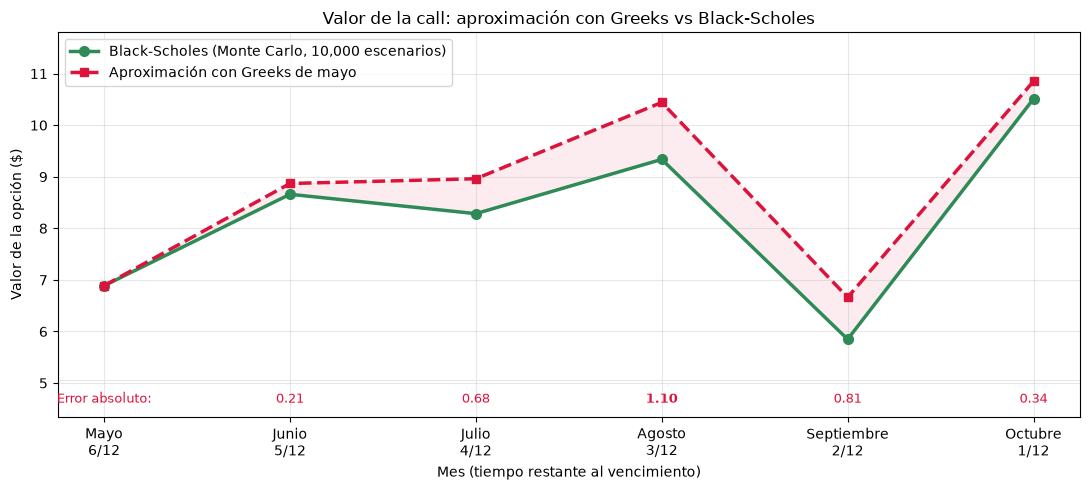

In [13]:
x = np.arange(6)
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(x, V_mc, lw=2.5, color='seagreen', marker='o', ms=7,
        label='Black-Scholes (Monte Carlo, 10,000 escenarios)', zorder=3)
ax.plot(x, V_greeks, lw=2.5, color='crimson', ls='--', marker='s', ms=6,
        label='Aproximación con Greeks de mayo', zorder=3)
ax.fill_between(x, V_mc, V_greeks, color='crimson', alpha=0.08)

# fila de errores al pie de la grafica
ax.axhline(5.05, color='#E5E7EB', lw=0.8)
ax.annotate("Error absoluto:", xy=(0, 4.62), ha='center', fontsize=9, color='crimson')
for i in range(1, 6):
    ax.annotate(f"{err_abs[i]:.2f}", xy=(x[i], 4.62), ha='center', fontsize=9.5,
                color='crimson', fontweight='bold' if i == i_abs else 'normal')

ax.set_xticks(x)
ax.set_xticklabels([f"{m}\n{int(t*12)}/12" for m, t in zip(meses, T_t)])
ax.set_ylim(4.35, 11.8)
ax.set_xlabel('Mes (tiempo restante al vencimiento)')
ax.set_ylabel('Valor de la opción ($)')
ax.set_title('Valor de la call: aproximación con Greeks vs Black-Scholes')
ax.legend(loc='upper left'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### ¿De dónde viene el error? Descomposición por factor

El error máximo coincide con los meses de mayor cambio en volatilidad, lo que invita a culpar a la Vega. Para comprobarlo, se aísla cada factor: se mueve solo ese factor, se compara su aproximación contra el cambio exacto de Black-Scholes, y lo que no explica ningún factor aislado se atribuye a la **interacción** entre factores.

In [14]:
filas = []
for i in range(1, 6):
    e_precio = (aporte_delta[i] + aporte_gamma[i]) - (precio_bs(S_t[i], K_, r_, 0.20, 0.5) - V0)
    e_vol    = aporte_vega[i]  - (precio_bs(100, K_, r_, sig_t[i], 0.5) - V0)
    e_tiempo = aporte_theta[i] - (precio_bs(100, K_, r_, 0.20, T_t[i]) - V0)
    e_total  = V_greeks[i] - V_cf[i]
    filas.append([meses[i], e_precio, e_vol, e_tiempo,
                  e_total - e_precio - e_vol - e_tiempo, e_total])

desc = pd.DataFrame(filas, columns=["Mes", "Precio (Delta+Gamma)", "Volatilidad (Vega)",
                                    "Tiempo (Theta)", "Interaccion", "Error total"])
print("Error de la aproximacion atribuible a cada factor (+ = sobreestima)\n")
print(desc.to_string(index=False))

print("\nVega real (S = 100, sigma = 20%) conforme se acerca el vencimiento:")
for m, t in zip(meses, T_t):
    d1_t = (np.log(100/K_) + (r_ + 0.5*0.2**2)*t) / (0.2*np.sqrt(t))
    print(f"   {m:<11} T = {int(t*12)}/12   Vega = {100*norm.pdf(d1_t)*np.sqrt(t)/100:.4f}")
print(f"   (La aproximacion usa {VEGA} todo el tiempo)")

Error de la aproximacion atribuible a cada factor (+ = sobreestima)

       Mes  Precio (Delta+Gamma)  Volatilidad (Vega)  Tiempo (Theta)  Interaccion  Error total
     Junio                0.0010              0.0357          0.0217       0.1490       0.2074
     Julio                0.0001              0.0678          0.0962       0.5113       0.6754
    Agosto                0.0179              0.0552          0.2447       0.7818       1.0996
Septiembre                0.0036              0.0150          0.5086       0.2822       0.8094
   Octubre                0.1583             -0.0000          0.9950      -0.8215       0.3318

Vega real (S = 100, sigma = 20%) conforme se acerca el vencimiento:
   Mayo        T = 6/12   Vega = 0.2736
   Junio       T = 5/12   Vega = 0.2510
   Julio       T = 4/12   Vega = 0.2257
   Agosto      T = 3/12   Vega = 0.1964
   Septiembre  T = 2/12   Vega = 0.1612
   Octubre     T = 1/12   Vega = 0.1146
   (La aproximacion usa 0.2814 todo el tiempo)


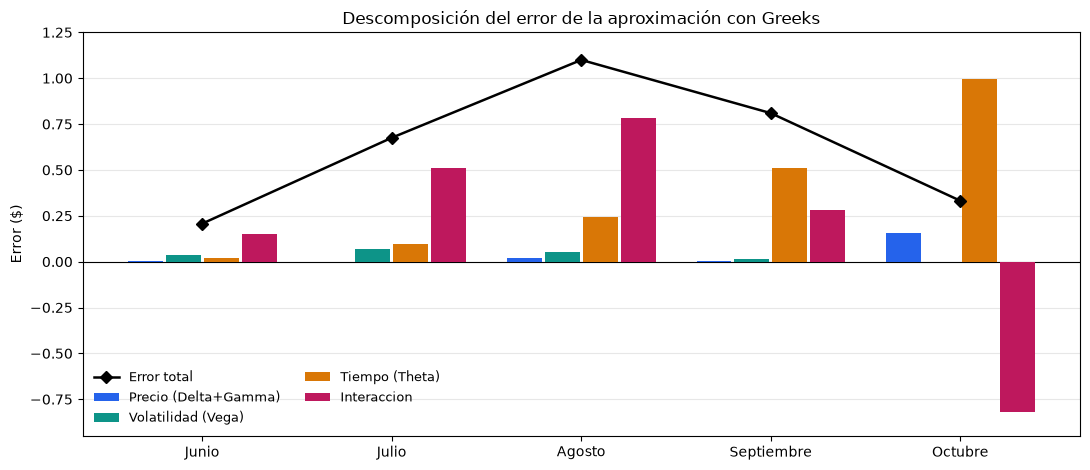

In [15]:
cols = ["Precio (Delta+Gamma)", "Volatilidad (Vega)", "Tiempo (Theta)", "Interaccion"]
colores = ["#2563EB", "#0D9488", "#D97706", "#BE185D"]
xx = np.arange(5); ancho = 0.2

fig, ax = plt.subplots(figsize=(11, 4.8))
for j, (c, col) in enumerate(zip(cols, colores)):
    ax.bar(xx + (j - 1.5)*ancho, desc[c], width=ancho*0.92, color=col, label=c, zorder=3)
ax.plot(xx, desc["Error total"], color='black', marker='D', lw=1.8, ms=6,
        label='Error total', zorder=4)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(xx); ax.set_xticklabels(meses[1:])
ax.set_ylabel('Error ($)')
ax.set_title('Descomposición del error de la aproximación con Greeks')
ax.set_ylim(-0.95, 1.25)
ax.legend(fontsize=9, ncol=2, loc='lower left', frameon=False); ax.grid(axis='y', alpha=0.3, zorder=0)
plt.tight_layout()
plt.show()

### Robustez: cambios mes a mes

Si la aproximación se construyera acumulando los cambios de cada mes contra el anterior, manteniendo las griegas de mayo, los términos lineales darían el mismo resultado y solo cambiaría el término de Gamma, que pasa de $\tfrac{1}{2}\Gamma(\sum dS)^2$ a $\sum \tfrac{1}{2}\Gamma\,dS^2$. Las conclusiones centrales se mantienen con ambos métodos: la aproximación sobreestima en todos los meses y el error máximo, de alrededor de 1.05 a 1.10, aparece en agosto-septiembre. La diferencia está en octubre, donde la versión mes a mes casi acierta (error de 0.01). Esto refuerza que el bajo error de octubre es producto de compensaciones entre términos, no de que la aproximación funcione bien ahí.

In [16]:
dS_m   = np.diff(S_t, prepend=S_t[0])
dsig_m = np.diff(sig_t, prepend=sig_t[0]) * 100
dt_m   = np.r_[0, np.ones(5)/12]
V_paso = V0 + np.cumsum(DELTA*dS_m + 0.5*GAMMA*dS_m**2 + VEGA*dsig_m + THETA*dt_m)

print(pd.DataFrame({
    "Mes": meses,
    "Greeks (desde mayo)": V_greeks,
    "Greeks (mes a mes)": V_paso,
    "Black-Scholes (MC)": V_mc,
    "Error desde mayo": np.abs(V_greeks - V_mc),
    "Error mes a mes": np.abs(V_paso - V_mc),
}).to_string(index=False))

       Mes  Greeks (desde mayo)  Greeks (mes a mes)  Black-Scholes (MC)  Error desde mayo  Error mes a mes
      Mayo               6.8887              6.8887              6.8874            0.0013           0.0013
     Junio               8.8695              8.8695              8.6602            0.2093           0.2093
     Julio               8.9614              9.0161              8.2848            0.6766           0.7313
    Agosto              10.4414             10.3867              9.3370            1.1044           1.0496
Septiembre               6.6624              6.8813              5.8492            0.8132           1.0321
   Octubre              10.8520             10.4964             10.5111            0.3409           0.0148


## Preguntas de la Parte 3

**1. ¿Los greeks iniciales describen con precisión toda la trayectoria?**

No. Funcionan bien solo al principio: en junio el error es de 0.21 (2.4% del valor). A partir de ahí se deteriora rápidamente, llegando a 1.10 en agosto (11.8%) y a 0.81 en septiembre (13.9%). Además, la aproximación **sobreestima el valor en todos los meses**: el sesgo no es aleatorio, es sistemático, lo que indica un error de modelo y no de ruido. Las griegas describen la opción en el punto donde se calcularon: mayo, con seis meses por delante, y ese punto deja de ser representativo conforme pasa el tiempo.

**2. ¿En qué mes apareció el error más grande?**

En **agosto**, con un error absoluto de 1.10 pesos. En términos relativos el peor mes es **septiembre** (13.9%), porque el valor de la opción es menor y el mismo error pesa más. Agosto acumula tres meses transcurridos, un aumento de 8 puntos en volatilidad y el mayor movimiento de precio hasta ese momento.

**3. ¿Qué factor parece contribuir más al error?**

A primera vista parece la **volatilidad**, porque el error máximo coincide con los meses de mayor $d\sigma$ (julio +10 pp, agosto +8 pp). Pero la descomposición muestra que la Vega, aislada, se equivoca muy poco: menos de 0.07 en todos los meses.

El verdadero responsable es el **paso del tiempo**, por dos vías:

- **Directamente:** la Theta no es constante. Se acelera conforme se acerca el vencimiento, y la aproximación la trata como fija. El error atribuible al tiempo crece de 0.02 en junio a 1.00 en octubre.
- **A través de la interacción con la volatilidad:** la Vega se calculó con seis meses por delante (0.27), pero se reduce con el tiempo restante: en agosto ya vale 0.20. La aproximación valúa el aumento de 8 puntos de volatilidad de agosto con la Vega de mayo, sobreestimando su efecto. Esta interacción explica 0.78 de los 1.10 de error en agosto.

El precio, en cambio, casi no contribuye: Delta y Gamma describen bien movimientos de hasta 5 pesos. Solo en octubre, con un alza de 10 pesos, aparece un error de precio relevante (0.16).

Octubre merece una observación aparte: su error total es pequeño (0.33) no porque la aproximación sea buena, sino porque dos errores grandes **se compensan**: el tiempo sobreestima en +1.00 y la interacción subestima en −0.82. Un error bajo no garantiza que el modelo esté funcionando.

**4. ¿Por qué los Greeks funcionan mejor para movimientos pequeños que para movimientos grandes?**

Porque son **derivadas**: miden la pendiente y la curvatura de la función de valor en un punto específico. La aproximación es una expansión de Taylor que se trunca en los primeros términos. Para movimientos pequeños, los términos omitidos (de orden superior y cruzados) son despreciables porque crecen con potencias del tamaño del movimiento. Para movimientos grandes, esos términos crecen más rápido que los que sí se incluyen y dominan el error.

Además, las griegas mismas cambian: la Delta cambia con el precio (eso mide la Gamma), la Vega cambia con el tiempo y con el precio, la Theta cambia con todo. Un movimiento grande lleva la opción a una región donde las griegas originales ya no describen su comportamiento.

**5. Si la trayectoria fuera mucho más volátil, ¿esperarías errores menores?**

No, **mayores**. Una trayectoria más volátil implica cambios más grandes en precio y en volatilidad, justo donde la aproximación local se rompe: los términos omitidos de la expansión crecen más que proporcionalmente con el tamaño del movimiento. Además, grandes cambios de volatilidad activarían las sensibilidades de segundo orden que la aproximación ignora por completo: la curvatura respecto a la volatilidad (*vomma*) y la interacción precio-volatilidad (*vanna*), La única forma de mantener la aproximación útil en un entorno así sería recalcular las griegas con mucha mayor frecuencia.

**6. Conclusión**

Las griegas son un **mapa local**, no una descripción global. Son una herramienta excelente para lo que fueron diseñadas: medir y cubrir el riesgo ante movimientos pequeños y en horizontes cortos. En este ejercicio, las griegas de mayo aproximan bien el primer mes, pero a partir de ahí sobreestiman de forma sistemática el valor de la opción, con errores de hasta 12-14%.

La decisión financiera que se desprende es clara: **las griegas deben recalcularse periódicamente**. Una mesa de derivados que cubriera esta posición con las sensibilidades de mayo estaría mal cubierta desde julio, y lo estaría sin saberlo, porque el error crece en silencio y a veces se esconde detrás de compensaciones, como en octubre.

El factor que más degrada la aproximación no es el que parece a primera vista. No es la volatilidad por sí sola, sino el **paso del tiempo** y la forma en que altera las demás sensibilidades. Para opciones que se acercan al vencimiento, la Theta y la Vega cambian rápido, y ahí es donde una cobertura estática resulta más riesgosa.